# Exercise 01: RL Fundamentals and MDPs
## AIAT 123 - Reinforcement Learning

---

## Learning Objectives

In this exercise, you will:
- Define Markov Decision Processes (MDPs)
- Implement value iteration algorithm
- Evaluate and compare policies
- Solve simple RL problems

---

## Real-World Context

You are solving a grid world navigation problem where an agent must find the optimal path to a goal while avoiding obstacles.

---


## Exercise Brief

This exercise checks whether students can do the core Unit 1 work on their own.

They must define an MDP clearly, run value iteration, and compare policies with short explanations.

Why this matters: Unit 1 is the conceptual base of the whole course, so students should not leave it with passive understanding only.

This exercise is designed to verify that the ideas from the lesson notebooks are now usable.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


### Step Guide

**What this cell does:** Install or import dependencies so later cells can run.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Pip progress lines and usually a confirmation that imports work.

**If you feel lost:** Fix any red install error before continuing—later cells assume this cell succeeded.


## Student Support Pack

Use this section before coding so you know what the exercise is testing conceptually.

### Key Terms
- State: where the agent is.
- Action: what the agent can do.
- Reward: immediate feedback.
- Policy: the action rule.

### Quick Check
- Can you separate environment pieces from agent pieces?
- Why do we define states and actions before solving?
- What part of the notebook tells you what success means?

### Common Mistakes
- Mixing state with reward.
- Thinking the policy creates the reward.
- Reading one transition as the whole problem.


In [1]:
# Setup step: install the small packages needed for this lesson.
# Students can rerun this cell if the environment is missing a dependency.

# Line magic: Jupyter/IPython directive for this line only.
%pip install numpy -q

# Load a library so you can use its ready-made functions and types below.
import numpy as np

# Use NumPy for fast numeric arrays and math on grids of numbers.
np.set_printoptions(precision=2, suppress=True)

# Show text or numbers in the cell output area under the code.
print("✅ Setup complete!")
# Show text or numbers in the cell output area under the code.
print("This exercise uses a small 3x3 grid-world MDP.")



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


✅ Setup complete!
This exercise uses a small 3x3 grid-world MDP.


## Task 1: MDP Definition (25 points)

Define the MDP for a simple problem (grid world, maze, or similar).

**Requirements:**
- Define states
- Define actions
- Define transition probabilities
- Define reward function

Teaching note: if your environment is deterministic, you can still describe transition probabilities. They are just concentrated on one outcome, so the chosen transition has probability `1.0`.

### Step Guide

**What this cell does:** Build the next chunk of the lesson (often a function, table, or training loop).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [2]:
# Teaching note: this cell advances the lesson by building the next piece of the RL workflow.
# Run it after reading the comments so the output feels connected to the concept being taught.

# Starter environment for Task 1
# Set grid height and width in cells (3x3 in this toy MDP).
N_ROWS, N_COLS = 3, 3
# Total number of states = rows * columns (flattened indices 0..N-1).
N_STATES = N_ROWS * N_COLS
# Create the list of action names (their indices are the numeric action ids).
ACTIONS = ["up", "right", "down", "left"]
# Save a value in a name so the next lines can read it.
ACTION_TO_DELTA = {
    # Dictionary/map entry: this key maps to the tuple/value on the right.
    0: (-1, 0),
    # Dictionary/map entry: this key maps to the tuple/value on the right.
    1: (0, 1),
    # Dictionary/map entry: this key maps to the tuple/value on the right.
    2: (1, 0),
    # Dictionary/map entry: this key maps to the tuple/value on the right.
    3: (0, -1),
# Part of a dict/set literal layout (syntax grouping).
}
# Pick which flat state ids are special terminals for rewards in transition().
GOAL_STATE = 8
# Pick which flat state ids are special terminals for rewards in transition().
PIT_STATE = 6
# Build the set of terminal state ids (used to skip Bellman backups).
TERMINAL_STATES = {GOAL_STATE, PIT_STATE}
# Set discount factor gamma used inside r + gamma * V(s') targets.
GAMMA = 0.90


# Function `to_pos` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: state.
def to_pos(state):
    # Send a value back to whoever called this function.
    return divmod(state, N_COLS)


# Function `to_state` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: row, col.
def to_state(row, col):
    # Send a value back to whoever called this function.
    return row * N_COLS + col


# Task 1a: complete the transition function.
# Function `transition` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: state, action.
def transition(state, action):
    # If the condition is True, run the indented block under this line.
    if state in TERMINAL_STATES:
        # Send a value back to whoever called this function.
        return state, 0.0

    # Save a value in a name so the next lines can read it.
    row, col = to_pos(state)
    # Another assignment—same idea: store a value for the lines below.
    d_row, d_col = ACTION_TO_DELTA[action]
    # Another assignment—same idea: store a value for the lines below.
    next_row = min(max(row + d_row, 0), N_ROWS - 1)
    # Another assignment—same idea: store a value for the lines below.
    next_col = min(max(col + d_col, 0), N_COLS - 1)
    # Unpack the one-step model output from transition(state, action).
    next_state = to_state(next_row, next_col)

    # If the condition is True, run the indented block under this line.
    if next_state == GOAL_STATE:
        # Send a value back to whoever called this function.
        return next_state, 10.0
    # If the condition is True, run the indented block under this line.
    if next_state == PIT_STATE:
        # Send a value back to whoever called this function.
        return next_state, -10.0
    # Send a value back to whoever called this function.
    return next_state, -1.0


# Task 1b: print example transitions to confirm your MDP definition.
# Start a loop: repeat the indented block once per item in the sequence.
for action in range(4):
    # Show text or numbers in the cell output area under the code.
    print(f"state 4 + action {ACTIONS[action]} ->", transition(4, action))


state 4 + action up -> (1, -1.0)
state 4 + action right -> (5, -1.0)
state 4 + action down -> (7, -1.0)
state 4 + action left -> (3, -1.0)


## Task 2: Value Iteration (40 points)

Implement the value iteration algorithm to find optimal value function.

**Requirements:**
- Implement value iteration
- Handle convergence
- Visualize value function
- Extract optimal policy


### Step Guide

**What this cell does:** Build the next chunk of the lesson (often a function, table, or training loop).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [3]:
# Teaching note: this cell advances the lesson by building the next piece of the RL workflow.
# Run it after reading the comments so the output feels connected to the concept being taught.

# Task 2: value iteration

# Function `value_iteration` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: gamma, theta.
def value_iteration(gamma=GAMMA, theta=1e-6):
    # Create or choose a variable used in the Bellman warm-up demo.
    values = np.zeros(N_STATES)
    # Start a loop: repeat the indented block while the condition stays True.
    while True:
        # Track how much the value table moved during the current sweep (or max change).
        delta = 0.0
        # Hold the updated V table for this sweep before swapping it into values.
        new_values = values.copy()
        # Start a loop: repeat the indented block once per item in the sequence.
        for state in range(N_STATES):
            # If the condition is True, run the indented block under this line.
            if state in TERMINAL_STATES:
                # Skip to the next lap of the loop (ignore the rest of this lap).
                continue
            # Create a Python list that will store one scalar target per action.
            action_returns = []
            # Start a loop: repeat the indented block once per item in the sequence.
            for action in range(len(ACTIONS)):
                # Unpack the one-step model output from transition(state, action).
                next_state, reward = transition(state, action)
                # Add one new item to the end of a list (the list grows in place).
                action_returns.append(reward + gamma * values[next_state])
            # Take the Bellman optimality max over the per-action backup list.
            best_value = max(action_returns)
            # Track how much the value table moved during the current sweep (or max change).
            delta = max(delta, abs(best_value - values[state]))
            # Hold the updated V table for this sweep before swapping it into values.
            new_values[state] = best_value
        # Create or choose a variable used in the Bellman warm-up demo.
        values = new_values
        # If the condition is True, run the indented block under this line.
        if delta < theta:
            # Stop the loop completely and continue after the loop block.
            break
    # Send a value back to whoever called this function.
    return values


# Task 2a: run value iteration.
# Create or choose a variable used in the Bellman warm-up demo.
values = value_iteration()
# Show text or numbers in the cell output area under the code.
print("Optimal values:", values)

# Task 2b: write a short explanation in markdown below:
# Why are states close to the goal higher-value than states near the pit?


Optimal values: [ 4.58  6.2   8.    6.2   8.   10.    0.   10.    0.  ]


## Task 3: Policy Evaluation (35 points)

Evaluate different policies and compare their performance.

**Requirements:**
- Implement policy evaluation
- Compare multiple policies
- Visualize policy performance
- Analyze results


### Step Guide

**What this cell does:** Build the next chunk of the lesson (often a function, table, or training loop).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [4]:
# Teaching note: this cell advances the lesson by building the next piece of the RL workflow.
# Run it after reading the comments so the output feels connected to the concept being taught.

# Task 3: policy evaluation and comparison

# Function `evaluate_policy` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: policy, gamma, theta.
def evaluate_policy(policy, gamma=GAMMA, theta=1e-6):
    # Create or choose a variable used in the Bellman warm-up demo.
    values = np.zeros(N_STATES)
    # Start a loop: repeat the indented block while the condition stays True.
    while True:
        # Track how much the value table moved during the current sweep (or max change).
        delta = 0.0
        # Start a loop: repeat the indented block once per item in the sequence.
        for state in range(N_STATES):
            # If the condition is True, run the indented block under this line.
            if state in TERMINAL_STATES:
                # Skip to the next lap of the loop (ignore the rest of this lap).
                continue
            # Save a value in a name so the next lines can read it.
            action = policy[state]
            # Unpack the one-step model output from transition(state, action).
            next_state, reward = transition(state, action)
            # Save a value in a name so the next lines can read it.
            new_value = reward + gamma * values[next_state]
            # Track how much the value table moved during the current sweep (or max change).
            delta = max(delta, abs(new_value - values[state]))
            # Create or choose a variable used in the Bellman warm-up demo.
            values[state] = new_value
        # If the condition is True, run the indented block under this line.
        if delta < theta:
            # Stop the loop completely and continue after the loop block.
            break
    # Send a value back to whoever called this function.
    return values


# Create or update the greedy policy array (one int action id per state).
policy_a = np.array([1, 1, 2, 1, 1, 2, 0, 1, 0])
# Create or update the greedy policy array (one int action id per state).
policy_b = np.array([1, 1, 2, 0, 0, 2, 0, 1, 0])

# Create or choose a variable used in the Bellman warm-up demo.
values_a = evaluate_policy(policy_a)
# Create or choose a variable used in the Bellman warm-up demo.
values_b = evaluate_policy(policy_b)

# Show text or numbers in the cell output area under the code.
print("Policy A values:", values_a)
# Show text or numbers in the cell output area under the code.
print("Policy B values:", values_b)

# Task 3a: compare the two policies.
# Task 3b: explain which policy is safer and why.
# Task 3c: identify one state where the policy choice matters most.


Policy A values: [ 4.58  6.2   8.    6.2   8.   10.    0.   10.    0.  ]
Policy B values: [ 4.58  6.2   8.    3.12  4.58 10.    0.   10.    0.  ]



---

## Submission

**Submission**: Complete notebook with all tasks implemented

**Grading**: 100 points total


## Reflection

Before submitting, make sure you can explain:

- how you defined the MDP
- how value iteration used the Bellman update
- why one policy performed better than another
- what the reward function encouraged in this environment

### Step Guide

**What this cell does:** Summarize or compare results (policies, returns, tables) for the lesson goal.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Tables, arrays, or comparison prints showing which policy or method wins.

**If you feel lost:** If output is empty, run the previous cells that define the data this cell consumes.


In [5]:
# Final computation: this cell usually summarizes the lesson, evaluates the result, or compares strategies.
# Pause here and ask what the numbers or tables say about the decision-making process.

# Submission checklist moved to the markdown cell below.

## Submission Checklist

Use this checklist before you submit:

- [ ] I defined the states, actions, terminal states, and rewards clearly.
- [ ] I ran value iteration successfully.
- [ ] I compared at least two policies.
- [ ] I wrote short explanations, not just code output.
- [ ] I checked my reasoning against the Unit 1 notes before submitting.

## 📝 Summary

In this notebook, you practiced:
- Formalizing a problem as a **Markov Decision Process** (states, actions, transition function, rewards, discount factor γ)
- Implementing **value iteration** to compute the optimal value function V*(s)
- Extracting an **optimal policy** from the value function using greedy action selection
- Solving a grid-world navigation task and evaluating different policies

**Next steps:** Move to Q-learning (Unit 2) and Deep Q-Networks (Unit 3) to tackle environments where the state space is too large for tabular methods.

In [6]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References & Further Reading

### Books
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

### Papers
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

### State-of-the-art OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.
"""))


## 📚 References & Further Reading

### Books
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

### Papers
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

### State-of-the-art OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.


### Step Guide

**What this cell does:** Draws the one figure this exercise is really about: the optimal value table `values` from Task 2 laid out on the actual 3x3 grid, and the two policies you scored in Task 3 compared tile by tile.

**How to read it (weak Python OK):** You do not need to follow the plotting code. It only re-draws numbers that were already printed above — nothing new is computed.

**What to expect in the output:** One figure with two panels: a coloured 3x3 grid of values on the left, and a paired bar chart on the right.

**If you feel lost:** If the cell errors with a `NameError`, re-run the Task 2 and Task 3 cells first — this figure reads `values`, `values_a` and `values_b` from them.


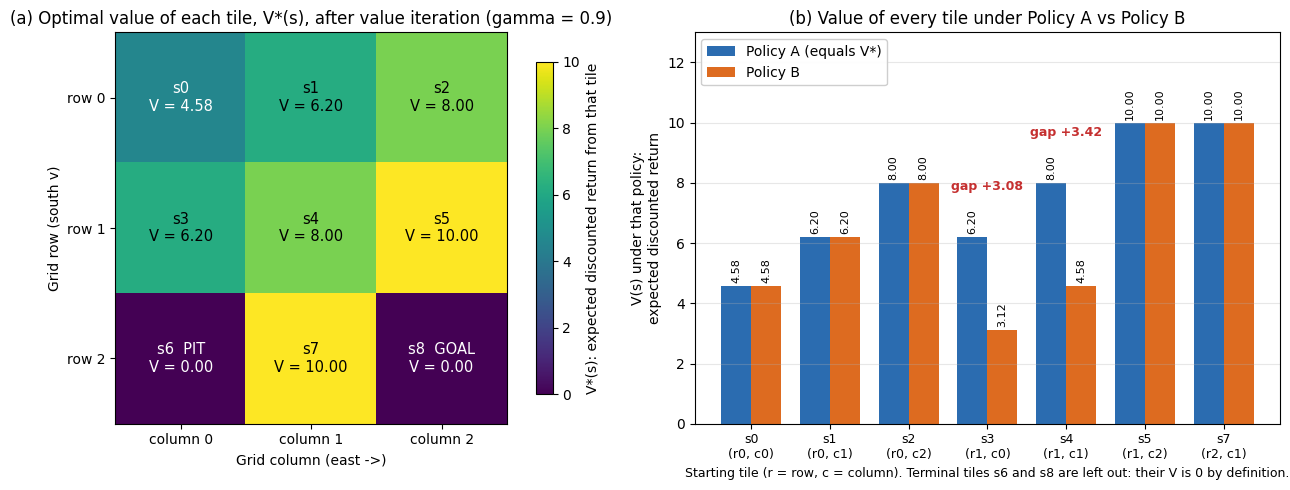

Tiles where Policy A and Policy B are worth different amounts: {'s3': 3.08, 's4': 3.42}


In [7]:
# Visual recap for this exercise: one figure carrying the two claims you just computed.
# Nothing new is calculated here — the numbers are exactly those printed by Task 2 and Task 3.

# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt
# Use NumPy for fast numeric arrays and math on grids of numbers.
import numpy as np

# The value table is a flat list of 9 numbers; fold it back into the 3x3 grid it came from.
v_grid = np.asarray(values, dtype=float).reshape(N_ROWS, N_COLS)

# One figure, two panels side by side.
fig, (ax_value, ax_policy) = plt.subplots(1, 2, figsize=(13.4, 5.0))

# ---------- Panel (a): the optimal value function drawn on the real grid ----------
# Colour each tile by its value, so "worth more" is visible without reading digits.
heat = ax_value.imshow(v_grid, cmap="viridis")
# Write the number inside every tile, plus a word for the two terminal tiles.
for state in range(N_STATES):
    row, col = to_pos(state)
    if state == GOAL_STATE:
        label = f"s{state}  GOAL\nV = {v_grid[row, col]:.2f}"
    elif state == PIT_STATE:
        label = f"s{state}  PIT\nV = {v_grid[row, col]:.2f}"
    else:
        label = f"s{state}\nV = {v_grid[row, col]:.2f}"
    # Dark text on the bright tiles, white text on the dark ones, so labels stay readable.
    ink = "black" if v_grid[row, col] > v_grid.max() * 0.55 else "white"
    ax_value.text(col, row, label, ha="center", va="center", color=ink, fontsize=10.5)

# Name the axes in words: these are grid coordinates, not array indices.
ax_value.set_xticks(range(N_COLS), labels=[f"column {c}" for c in range(N_COLS)])
ax_value.set_yticks(range(N_ROWS), labels=[f"row {r}" for r in range(N_ROWS)])
ax_value.set_xlabel("Grid column (east ->)")
ax_value.set_ylabel("Grid row (south v)")
ax_value.set_title(f"(a) Optimal value of each tile, V*(s), after value iteration (gamma = {GAMMA})")
# The colour bar says what the colour means, in the units of the problem.
bar = fig.colorbar(heat, ax=ax_value, shrink=0.85)
bar.set_label("V*(s): expected discounted return from that tile")

# ---------- Panel (b): the two policies from Task 3, scored on the same tiles ----------
# Terminal tiles are skipped: value iteration never backs them up, so their V is 0 by definition.
tiles = [s for s in range(N_STATES) if s not in TERMINAL_STATES]
va = [float(values_a[s]) for s in tiles]
vb = [float(values_b[s]) for s in tiles]
x = np.arange(len(tiles))
width = 0.38

# States are separate places, not a continuous quantity, so they get bars — never a joining line.
bars_a = ax_policy.bar(x - width / 2, va, width,
                       label="Policy A" + (" (equals V*)" if np.allclose(values_a, values, atol=1e-6) else ""),
                       color="#2b6cb0")
bars_b = ax_policy.bar(x + width / 2, vb, width,
                       label="Policy B" + (" (equals V*)" if np.allclose(values_b, values, atol=1e-6) else ""),
                       color="#dd6b20")
# Rotate the value labels so the two bars in a pair can never print on top of each other.
ax_policy.bar_label(bars_a, fmt="%.2f", fontsize=8, padding=2, rotation=90)
ax_policy.bar_label(bars_b, fmt="%.2f", fontsize=8, padding=2, rotation=90)

# Call out, in the picture, exactly where the two policies actually disagree in value.
for pos, state, a_val, b_val in zip(x, tiles, va, vb):
    gap = a_val - b_val
    if abs(gap) > 0.01:
        ax_policy.annotate(f"gap {gap:+.2f}", xy=(pos, max(a_val, b_val)),
                           xytext=(0, 34), textcoords="offset points",
                           ha="center", fontsize=9, color="#c53030", fontweight="bold")

ax_policy.set_xticks(x, labels=[f"s{s}\n(r{to_pos(s)[0]}, c{to_pos(s)[1]})" for s in tiles], fontsize=9)
ax_policy.set_xlabel("Starting tile (r = row, c = column). Terminal tiles s6 and s8 are left out: their V is 0 by definition.", fontsize=9)
ax_policy.set_ylabel("V(s) under that policy:\nexpected discounted return")
ax_policy.set_title("(b) Value of every tile under Policy A vs Policy B")
ax_policy.legend(loc="upper left", framealpha=0.95)
ax_policy.margins(y=0.30)
ax_policy.grid(axis="y", alpha=0.3)

fig.tight_layout()
# Draw the figure in the notebook output area.
plt.show()

# Say in words what the picture shows, so the numbers and the figure cannot drift apart.
gaps = {s: float(values_a[s] - values_b[s]) for s in range(N_STATES) if abs(values_a[s] - values_b[s]) > 1e-6}
# Show text or numbers in the cell output area under the code.
print("Tiles where Policy A and Policy B are worth different amounts:",
      {f"s{s}": round(g, 2) for s, g in gaps.items()} or "none")


### 👁️ Read the figure

- **Panel (a) — where the value comes from.** The grid is bright on the right and along the bottom-middle, and dimmest at `s0` (top-left, V* = 4.58). Value is not the reward you get *at* a tile; it is what you can still collect *from* it. Standing on `s5`, one step above the goal, is worth 10.00; standing three moves away at `s0` is worth 4.58, because each of the moves in between costs −1 and everything after them is discounted by γ = 0.90.
- **Read the two terminal tiles carefully — this is the trap.** `s6` (PIT) and `s8` (GOAL) both show **V = 0**, and they are the darkest tiles on the map. That does *not* mean the goal is worthless and the pit is harmless. Value iteration never backs up a terminal state, so its V stays at its initial 0. The +10 and the −10 are paid on the *transition into* those tiles, which is why the tiles *next to* them are the brightest (s5 and s7 = 10.00) and why the neighbours of the pit are still fine — the optimal policy simply never steps in.
- **Panel (b) — what Task 3 actually proved.** The two policies are identical on five of the seven non-terminal tiles: same bar height, no gap label. They differ only at `s3` (gap +3.08) and `s4` (gap +3.42), the two tiles where Policy B turns *up*, away from the goal, instead of right. Policy A's bars reproduce panel (a) exactly — the legend says `equals V*`, so Policy A is optimal here, and Policy B is not.
- **The difference is detour cost, not danger.** Neither policy ever enters the pit, so nobody is being punished with −10. Policy B just walks the long way round, and each extra step costs −1 and pushes the +10 one more discount factor into the future. If a classmate calls Policy B "the safer one", ask them to point at the tile where it avoids a risk that Policy A takes — there isn't one.
- These are bars, not a line, on purpose: `s0 … s7` are nine separate places on a map. There is no "between s3 and s4" to interpolate through.


## Closing Takeaway

**Teaching takeaway:** This exercise confirms that students can define and solve a small RL problem without relying on guided explanation.

**If students remember one idea:** If a student can clearly define the MDP and justify the policy behavior, then Unit 1 concepts are becoming usable knowledge.

**Quick check before moving on:**
- Can you justify each part of your MDP design rather than only writing it down?
- Can you explain what your policy or values mean in plain language?

**Bridge to the next step:** After this exercise, students are ready to learn how value functions and policies are learned from experience in Unit 2.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=6 | term=True | trunc=False


objc[70554]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x113d58138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1142549c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[70554]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x113d58188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114254a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[70554]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x113d57c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114254a68). T

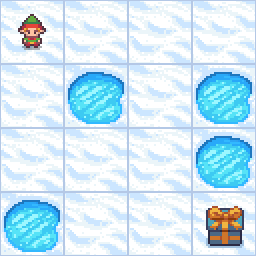

In [8]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
